# Maryland Automotive Industry : Chapter 4 - ARIMA Models
Total cars sold and real value of cars sold have been proven to move very strongly between one another until 2020 this was when Covid-19 impacted the global supply chains and the average pricee of cars sky rocketed. By splitting up the data into ne and used total cars sold it can be a more accurate prediction of these models that move independently to one another and will have different parameters influencing them at different levels.
#### New Cars Sold 
New cars have a higher average price but are less frequent within the industry. New cars also had a much bigger impact post 2020 because of the supply chain disruptions that were present that led to the number of battery packs, circuit chargers and other essential car parts that were usually used in production were haulted. 

#### Used Cars Sold
Used cars have a lower average price but take up about 2/3's of the sales of cars within Maryland. Used cars were not distrupted by the supply chain issues that took place but the average price of these cars did increase as a result in the rise of new cars sold resulting the average price of total cars growing which was the reason fo r the value of cars sold following 2020 having a steady growth while the total cars sold decreased. This will be looked at more.

### Import Packages

In [43]:
import pandas as pd # for dataframe
import numpy as np # for mathematical

In [44]:
# import evaluation packages
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [45]:
# import arima packages
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

In [46]:
# import grid spec
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

### Import Data
Using the data that has had irregularities removed and has been deseasonalised will be best to focus on the movements of the data rather than the individual sales that happen from month to month.

In [47]:
irregularities_removed_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/seasonal_decomposition/irr_removed_sales_data.csv')
irregularities_removed_data

,date,total_cars_sold,new_cars_sold,used_cars_sold,real_value_cars_sold,real_new_value_cars_sold,real_used_value_cars_sold
0,2002-01-31,81033,31106,49927,1983276860,1311790064,671486797
1,2002-02-28,78502,27520,50982,1779268812,1152499583,626769229
2,2002-03-31,93019,34225,58794,2118906951,1393518250,725388702
3,2002-04-30,96269,36452,59817,2203087599,1457386731,745700868
4,2002-05-31,97936,37359,60577,2231843792,1470619476,761224317
...,...,...,...,...,...,...,...
259,2023-08-31,78601,25876,52725,2148818539,1232783817,916034722
260,2023-09-30,69278,23892,48043,1888005721,1139805538,748200184
261,2023-10-31,69248,23775,45473,1870599863,1127101054,743498810
262,2023-11-30,64980,22720,42260,1760750411,1064941698,695808714


In [48]:
deseasonalised_sales_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/seasonal_decomposition/cyclical_data.csv')
deseasonalised_sales_data

,date,total_cars_sold,new_cars_sold,used_cars_sold,real_value_cars_sold,real_new_value_cars_sold,real_used_value_cars_sold
0,2002-01-31,89211.636364,32128.060606,57086.753788,2.040573e+09,1.306241e+09,7.343742e+08
1,2002-02-28,90198.318182,33388.787879,56808.071970,2.108439e+09,1.381781e+09,7.276463e+08
2,2002-03-31,85240.954545,33241.742424,51829.844697,2.047125e+09,1.373544e+09,6.709275e+08
3,2002-04-30,89819.590909,34646.378788,55176.390152,2.134552e+09,1.424029e+09,7.212525e+08
4,2002-05-31,92093.181818,34892.015152,57204.299242,2.153645e+09,1.424879e+09,7.377548e+08
...,...,...,...,...,...,...,...
259,2023-08-31,72335.545455,24075.833333,47990.662879,2.014189e+09,1.155990e+09,8.511289e+08
260,2023-09-30,67325.454545,22306.333333,47558.526515,1.808565e+09,1.067845e+09,7.368013e+08
261,2023-10-31,68829.045455,24225.878788,44748.708333,1.846941e+09,1.125836e+09,7.235529e+08
262,2023-11-30,74532.954545,26698.469697,48331.162879,1.941684e+09,1.188839e+09,7.534438e+08


### Import Functions

#### Adf Testing
- ADF Test
- Difference Data Until 95% confidence data is stationary

In [49]:
def adf_test(data):
    """Perform the ADF test to check for stationarity."""
    test_results = adfuller(data)
    adf_statistic = test_results[0]
    p_value = test_results[1]
    critical_values = test_results[4]

    print('ADF Statistic: ', adf_statistic)
    print('P-Value: ', p_value)
    print('Critical Values:')
    for thres, adf_stat in critical_values.items():
        print(f'\t{thres}: {adf_stat:.2f}')

    return p_value, adf_statistic, critical_values

In [50]:
def difference_until_stationary(data, max_diff=5, significance_level=0.05):
    """
    Applies differencing until the data is stationary based on the ADF test, 
    and plots the series before each differencing.
    
    Parameters:
    - data: Time series data (array-like).
    - max_diff: Maximum number of differences to apply (default is 5).
    - significance_level: The p-value threshold to determine stationarity (default is 0.05).
    
    Returns:
    - diff_data: The differenced data series.
    - d: The number of differences applied.
    """
    p_value, adf_stat, critical_values = adf_test(data)
    d = 0
    
    while p_value > significance_level and d < max_diff:
        # Plot the current state of the data
        plt.figure(figsize=(10, 4))
        plt.plot(data, label=f"Order of Differencing: {d}")
        plt.title(f"Original Time Series Data (Order of Differencing: {d})")
        plt.legend()
        plt.show()

        # Apply differencing
        d += 1
        data = np.diff(data, n=1)
        print(f"\nDifferencing Order: {d}")
        p_value, adf_stat, critical_values = adf_test(data)
    
    # Final plot after the last differencing
    plt.figure(figsize=(10, 4))
    plt.plot(data, label=f"Final Differencing (Order: {d})")
    plt.title(f"Seasonally Adjusted Time Series Data (Final Differencing Order: {d})")
    plt.legend()
    plt.show()
    
    if p_value > significance_level:
        print(f"\nWarning: The data is not stationary after {d} differences.")
    else:
        print(f"\nThe series became stationary after {d} differences.")
    
    return data, d

#### ARIMA Testing

In [51]:
def arima_analysis(data, sa_data):

    # Differencing until stationary
    differenced_data, d = difference_until_stationary(data)
    differenced_sa_data, D = difference_until_stationary(sa_data)

    # Create the overall figure and GridSpec
    fig = plt.figure(figsize=(14,8))
    gs = GridSpec(4, 8, figure=fig)

    # Original data plot
    ax_o_data = fig.add_subplot(gs[0:2, 0:5])
    ax_o_data.plot(data)
    ax_o_data.set_title('Original Data')

    # ACF plot for original data
    ax_o_acf = fig.add_subplot(gs[0:1, 5:8])
    plot_acf(data, ax=ax_o_acf, lags=5)
    ax_o_acf.set_title('ACF of Original Data')

    # PACF plot for original data
    ax_o_pacf = fig.add_subplot(gs[1:2, 5:8])
    plot_pacf(data, ax=ax_o_pacf, lags=5)
    ax_o_pacf.set_title('PACF of Original Data')

    # Seasonally Adjusted data plot
    ax_sa_data = fig.add_subplot(gs[2:4, 0:5])
    ax_sa_data.plot(sa_data)
    ax_sa_data.set_title('Seasonally Adjusted Data')

    # ACF plot for seasonally adjusted data
    ax_sa_acf = fig.add_subplot(gs[2:3, 5:8])
    plot_acf(sa_data, ax=ax_sa_acf, lags=5)
    ax_sa_acf.set_title('ACF of Seasonally Adjusted Data')

    # PACF plot for seasonally adjusted data
    ax_sa_pacf = fig.add_subplot(gs[3:4, 5:8])
    plot_pacf(sa_data, ax=ax_sa_pacf, lags=5)
    ax_sa_pacf.set_title('PACF of Seasonally Adjusted Data')

    # Adjust layout
    plt.tight_layout()
    plt.show()

    return d, D

In [52]:
warnings.filterwarnings("ignore", message="No frequency information was provided, so inferred frequency")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def evaluate_time_series_models(data, ar_orders, ma_orders, d_orders):
    results = []

    # Evaluate AR models
    for p in ar_orders:
        try:
            model = ARIMA(data, order=(p, 0, 0)).fit()
            results.append(('AR', (p, 0, 0), model.aic, model.bic))
        except Exception as e:
            continue

    # Evaluate MA models
    for q in ma_orders:
        try:
            model = ARIMA(data, order=(0, 0, q)).fit()
            results.append(('MA', (0, 0, q), model.aic, model.bic))
        except Exception as e:
            continue

    # Evaluate ARMA models
    for p, q in product(ar_orders, ma_orders):
        try:
            model = ARIMA(data, order=(p, 0, q)).fit()
            results.append(('ARMA', (p, 0, q), model.aic, model.bic))
        except Exception as e:
            continue

    # Evaluate ARIMA models
    for p, d, q in product(ar_orders, d_orders, ma_orders):
        try:
            model = ARIMA(data, order=(p, d, q)).fit()
            results.append(('ARIMA', (p, d, q), model.aic, model.bic))
        except Exception as e:
            continue

    result_df = pd.DataFrame(results, columns=['Model', 'Order', 'AIC', 'BIC'])
    return result_df.sort_values(by=['AIC'])

In [53]:
def select_best_sarima_model(data, p_list, d_list, q_list, P_list, D_list, Q_list, s):
   
    # Expand the parameter space for auto_arima to search
    model = auto_arima(data, start_p=min(p_list), d=min(d_list), start_q=min(q_list),
                       max_p=max(p_list), max_d=max(d_list), max_q=max(q_list),
                       start_P=min(P_list), D=min(D_list), start_Q=min(Q_list),
                       max_P=max(P_list), max_D=max(D_list), max_Q=max(Q_list),
                       seasonal=True, m=s, stepwise=True,
                       suppress_warnings=True, trace=False,
                       error_action='ignore', information_criterion='aic')

    # Extract the AIC and BIC from the selected model
    results = {
        'aic': model.aic(),
        'bic': model.bic(),
        'pdq': model.order,
        'seasonal_pdq': model.seasonal_order
    }
   
    return results

#### Forecasting Model

In [54]:
def test_training_model(train_data, test_data, predictions,
                        x_label, y_label, title,prediction_label):
    # Plot original data
    plt.figure(figsize=(10, 6))
    plt.plot(train_data.index, train_data['Sales'], label='Train Data', color='cornflowerblue')
    plt.plot(test_data.index, test_data['Sales'], label='Test Data', color='mediumseagreen')
    plt.plot(predictions.index, predictions, label=prediction_label, color='darkorange',linestyle='--')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend()

    # Show plot
    plt.show()

In [55]:
def model_forecast(original_data, original_data_sales, predictions,
                        x_label, y_label, title, prediction_label):
    # Plot original data
    plt.figure(figsize=(10, 6))
    plt.plot(original_data.index, original_data_sales, label='Original Data', color='cornflowerblue')
    plt.plot(predictions.index, predictions, label=prediction_label, color='mediumseagreen', linestyle='--')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend()

    # Show plot
    plt.show()

## New Cars Sold ARIMA Modeling
Use original cars sold to identify pdq
Use deseasonalised cars sold to identify PDQ

The deseasonalised data has been found in a previous chapter where manul deseasonalisation took place by removing irregularities then lookinat the average price of cars sold

In [118]:
from sklearn.model_selection import train_test_split
# split data into train and test for irregularities removed
new_cars_train, new_cars_test = train_test_split(irregularities_removed_data[['date','new_cars_sold']],test_size= 0.2,shuffle=False)

# split data into train and test for deseasonalised irregularities removed
new_cars_deseasonalised_train, new_cars_deseasonalised_test = train_test_split(deseasonalised_sales_data[['date','new_cars_sold'],test_size=0.2,shuffle=False)

SyntaxError: invalid syntax (4251966837.py, line 6)

In [117]:
new_cars_train

,date,new_cars_sold
0,2002-01-31,31106
1,2002-02-28,27520
2,2002-03-31,34225
3,2002-04-30,36452
4,2002-05-31,37359
...,...,...
206,2019-03-31,26485
207,2019-04-30,30044
208,2019-05-31,29396
209,2019-06-30,29142


### Finding Parameters

In [116]:
arima_analysis(new_cars_train['new_cars_sold'],new_cars_deseasonalised_train)

ValueError: could not convert string to float: '2002-01-31'

In [74]:
# create lists of values that can be used for pdq and PDQ for new cars sold
new_cars_p_list = [1,2,3]
new_cars_d_list = [0,1]
new_cars_q_list = [1,4]

new_cars_P_list = [1,2,3]
new_cars_D_list = [0,1]
new_cars_Q_list = [1]

### Model Evaluation

In [72]:
# create arima models
evaluate_time_series_models(new_cars_train,new_cars_p_list,new_cars_q_list,new_cars_d_list)

,Model,Order,AIC,BIC
14,ARIMA,"(1, 1, 4)",3988.024285,4008.106930
18,ARIMA,"(2, 1, 4)",3988.553097,4011.982850
22,ARIMA,"(3, 1, 4)",3991.856814,4018.633674
12,ARIMA,"(1, 0, 4)",4014.012229,4037.475236
6,ARMA,"(1, 0, 4)",4014.012229,4037.475236
4,MA,"(0, 0, 4)",4026.422879,4046.534028
21,ARIMA,"(3, 1, 1)",4031.067256,4047.802793
17,ARIMA,"(2, 1, 1)",4035.455151,4048.843581
19,ARIMA,"(3, 0, 1)",4039.405055,4059.516204
9,ARMA,"(3, 0, 1)",4039.405055,4059.516204


Observe that the lowest AIC and BIC values came to those who had higher complexities, including differencing, moving average as well as autoregressive meanwhile those that isolated on those attributes did not perform as well.

In [75]:
# create sarima model
select_best_sarima_model(new_cars_train,new_cars_p_list,new_cars_d_list,new_cars_q_list,new_cars_P_list,new_cars_D_list,new_cars_Q_list,12)

{'aic': 3851.1026288085377,
 'bic': 3871.213777609394,
 'pdq': (1, 0, 2),
 'seasonal_pdq': (1, 0, 1, 12)}

### Model Forecast
The best model is the SARIMA (1,0,1) (1,0,1,12) 

Based on both the AIC and BIC, this is expected as the seasonal decomposition showed the strong impacts of removing seasonality in smoothing the data.

In [77]:
# train model
sarima_model = SARIMAX(new_cars_train, 
                           order=(1, 0, 1), 
                           seasonal_order=(1, 0, 1, 12),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
sarima_results = sarima_model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.69654D+00    |proj g|=  2.47226D-01

At iterate    5    f=  8.66005D+00    |proj g|=  1.07383D-01

At iterate   10    f=  8.65896D+00    |proj g|=  1.32096D-03

At iterate   15    f=  8.65896D+00    |proj g|=  6.67072D-04

At iterate   20    f=  8.65893D+00    |proj g|=  1.25761D-02

At iterate   25    f=  8.65449D+00    |proj g|=  1.30554D-01

At iterate   30    f=  8.54951D+00    |proj g|=  6.28435D-01

At iterate   35    f=  8.47944D+00    |proj g|=  4.08302D-01

At iterate   40    f=  8.47375D+00    |proj g|=  1.24525D-03

At iterate   45    f=  8.47375D+00    |proj g|=  1.82302D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

 This problem is unconstrained.


In [80]:
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      new_cars_sold   No. Observations:                  211
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -1787.961
Date:                            Fri, 30 Aug 2024   AIC                           3585.923
Time:                                    21:17:30   BIC                           3602.339
Sample:                                         0   HQIC                          3592.568
                                            - 211                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9839      0.010     98.262      0.000       0.964       1.004
ma.L1         -0.6372      0.039   

In [83]:
# forecast the test period
new_cars_prediction = sarima_results.get_forecast(steps=len(new_cars_test))
new_cars_prediction

In [85]:
forecasted_values = new_cars_prediction.predicted_mean
pred_ci = new_cars_prediction.conf_int()

In [88]:
mae = mean_absolute_error(new_cars_test, forecasted_values)
mse = mean_squared_error(new_cars_test, forecasted_values)
rmse = np.sqrt(mse)

In [89]:
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 2755.940703555478
Mean Squared Error: 11513260.226025432
Root Mean Squared Error: 3393.119541959203


In [114]:
new_cars_train

0      31106
1      27520
2      34225
3      36452
4      37359
       ...  
206    26485
207    30044
208    29396
209    29142
210    30821
Name: new_cars_sold, Length: 211, dtype: int64

In [113]:
# create a function which analysis sarima mode
def sarima_model_analysis(train_data,test_data,p,d,q,P,D,Q,s,forecast_periods):
    """
    Create a function to analyse the success of a sarima model

    paramaeters:
    - train_data : the data that was used to train the model
    - test_data : the data that was a part of the original series but will be used to analyse the accuracy of the model
    - p,d,q : the non seasonal arima parameters
    - P,D,Q : the seasonal arima parameters
    - s : the seasonal period
    - forecast_periods : the number of values to predict into the future 

    returns:
    forecast_summary : observe key metrics to understand success of the forecast
    model_evaluation : look at mae
    plot_forecast : plot the forecasted data with the actually test data
    acf_plot : look at the acf plot to ensure that there is no autoregression
    residual_analysis : look at the residual plot of the difference to ensure that it has random error
    """

    # fit the sarima model to the training data
    sarima_model = SARIMAX(train_data,
                           order = (p,d,q),
                           seasonal_order=(P,D,Q,s),
                           enforce_invertibility=False,
                           enforce_stationarity=False)
    
    # get the sarima results
    sarima_results = sarima_model.fit(disp=False) # disp=False is going to not print errors associated with SARIMA model building

    # print the key metrics associated with the sarima model fitting
    print(sarima_results.summary())

    
    # create a forecast for the test period
    predictions = sarima_results.get_forecast(steps=len(test_data))

    # create the forecasted values
    forecasted_values = predictions.predicted_mean
    # create the prediction intervals for the forecast values
    pred_ci = predictions.conf_int()



    # evaluate performance
    mae = mean_absolute_error(test_data, forecasted_values)
    print(f'The mean absolute error is {mae}')


    # plot forecast vs original test data
    plt.figure(figsize=(10, 6))
    plt.plot(train_data, train_data, label='Training Data')
    plt.plot(test_data, test_data, label='Test Data')
    plt.plot(test_data, forecasted_values, color='red', label='Forecasted Data')
    plt.fill_between(test_data, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='red', alpha=0.3)
    plt.xlabel('Date')
    plt.ylabel('Values')
    plt.title('SARIMA Model Forecast vs Actual')
    plt.legend()
    plt.show()


In [110]:
def finalize_sarima_model(train_data, test_data, p, d, q, P, D, Q, s, forecast_periods,original_date_index):
    """
    Function to fit, evaluate, and forecast using a SARIMA model.

    Parameters:
    - train_data: Training dataset (Pandas Series)
    - test_data: Testing dataset (Pandas Series)
    - p, d, q: Non-seasonal ARIMA parameters
    - P, D, Q: Seasonal ARIMA parameters
    - s: Seasonal period
    - forecast_periods: Number of periods to forecast into the future (default is 12)

    Returns:
    - forecasted_values: Forecasted values for the test period
    - future_forecasted_values: Forecasted values for future periods
    - sarima_results: Fitted SARIMA model results object
    """
    
    # Fit the SARIMA model on the training data
    sarima_model = SARIMAX(train_data, 
                           order=(p, d, q), 
                           seasonal_order=(P, D, Q, s),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
    sarima_results = sarima_model.fit(disp=False)

    # Print the model summary
    print(sarima_results.summary())

    # Forecast for the test period
    predictions = sarima_results.get_forecast(steps=len(test_data))

    # Get forecasted values and confidence intervals
    forecasted_values = predictions.predicted_mean
    pred_ci = predictions.conf_int()

    # Evaluate the model's performance
    mae = mean_absolute_error(test_data, forecasted_values)
    mse = mean_squared_error(test_data, forecasted_values)
    rmse = np.sqrt(mse)

    print(f'Mean Absolute Error: {mae}')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}')

    # create timestamps for the first 80% and last 20%
    original_date_train = original_date_index['date'].iloc[0:len(test_data)]

    original_date_test = original_date_index['date'].iloc[len(test_data):]

    # Plotting the test data vs. forecasted values
    plt.figure(figsize=(10, 6))
    plt.plot(original_date_train, train_data, label='Training Data')
    plt.plot(original_date_test, test_data, label='Test Data')
    plt.plot(original_date_test, forecasted_values, color='red', label='Forecasted Data')
    plt.fill_between(original_date_test, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], color='red', alpha=0.3)
    plt.xlabel('Date')
    plt.ylabel('Values')
    plt.title('SARIMA Model Forecast vs Actual')
    plt.legend()
    plt.show()

    # Plot residuals
    residuals = sarima_results.resid
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.hist(residuals, bins=20)
    plt.title('Histogram of Model Residuals')
    plt.subplot(2, 1, 2)
    plot_acf(residuals, lags=30)
    plt.title('ACF of Model Residuals')
    plt.tight_layout()
    plt.show()

    # Forecasting into the future
    future_forecast = sarima_results.get_forecast(steps=forecast_periods)
    future_forecasted_values = future_forecast.predicted_mean
    future_ci = future_forecast.conf_int()

    # Plotting future forecast
    plt.figure(figsize=(10, 6))
    plt.plot(train_data.index.union(test_data.index), 
             train_data.append(test_data), label='Historical Data')
    plt.plot(pd.date_range(start=test_data.index[-1], periods=forecast_periods, freq='M'),
             future_forecasted_values, color='red', label='Future Forecast')
    plt.fill_between(pd.date_range(start=test_data.index[-1], periods=forecast_periods, freq='M'), 
                     future_ci.iloc[:, 0], future_ci.iloc[:, 1], color='red', alpha=0.3)
    plt.xlabel('Date')
    plt.ylabel('Values')
    plt.title('Future Sales Forecast')
    plt.legend()
    plt.show()

    return forecasted_values, future_forecasted_values, sarima_results

# Example usage:
# forecasted_values, future_forecasted_values, sarima_results = finalize_sarima_model(new_cars_train, new_cars_test, 1, 0, 1, 1, 0, 1, 12)


In [106]:
irregularities_removed_data['date'].iloc[]

0      2002-01-31
1      2002-02-28
2      2002-03-31
3      2002-04-30
4      2002-05-31
          ...    
259    2023-08-31
260    2023-09-30
261    2023-10-31
262    2023-11-30
263    2023-12-31
Name: date, Length: 264, dtype: object

                                     SARIMAX Results                                      
Dep. Variable:                      new_cars_sold   No. Observations:                  211
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -1787.961
Date:                            Fri, 30 Aug 2024   AIC                           3585.923
Time:                                    21:36:55   BIC                           3602.339
Sample:                                         0   HQIC                          3592.568
                                            - 211                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9839      0.010     98.262      0.000       0.964       1.004
ma.L1         -0.6372      0.039   

ValueError: x and y must have same first dimension, but have shapes (53,) and (211,)

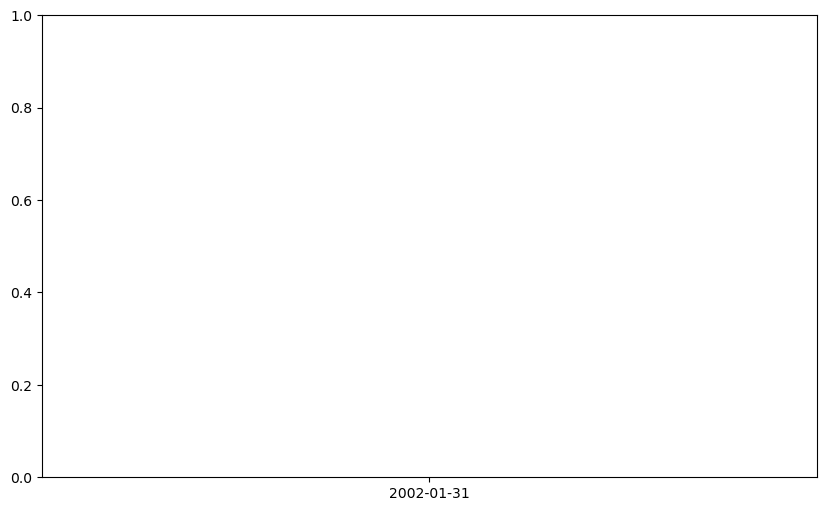

In [111]:
finalize_sarima_model(new_cars_train,new_cars_test,1,0,1,1,0,1,12,len(new_cars_test),irregularities_removed_data)

In [ ]:
orig